# Chương 6 - Demo

Notebook này minh họa các nội dung quan trọng trong **Chương 6: The universal workflow of Machine Learning** bằng một bài toán nhỏ: **dự đoán khách hàng có rời bỏ dịch vụ trong 30 ngày tới hay không**.

Notebook được viết theo hướng dễ học:

- Dùng **Keras** để xây dựng mô hình.
- Dùng **Keras preprocessing layers** để chuẩn hóa và mã hóa dữ liệu.

Workflow chính:

1. Xác định bài toán.
2. Tạo và hiểu dữ liệu.
3. Chọn metric.
4. Chia train / validation / test.
5. Tạo preprocessing bằng Keras.
6. Tạo baseline.
7. Huấn luyện mô hình Keras đơn giản.
8. Thử model lớn để thấy overfitting.
9. Dùng regularization và early stopping.
10. Đánh giá test set.
11. Lưu inference model.
12. Mô phỏng production drift và monitoring.


## 0. Thiết lập môi trường

Notebook dùng các thư viện quen thuộc:

- `numpy`, `pandas`: tạo và xử lý dữ liệu dạng bảng.
- `matplotlib`: vẽ biểu đồ.
- `scikit-learn`: chia dữ liệu và tính metric.
- `tensorflow.keras`: xây dựng, huấn luyện và lưu mô hình.

In [1]:
# Nếu chạy local mà thiếu TensorFlow, cài bằng:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:

# Import thư viện warnings để kiểm soát cảnh báo khi chạy notebook.
import warnings

# Ẩn các cảnh báo không quan trọng để output dễ đọc hơn cho người mới học.
warnings.filterwarnings("ignore")

# Import Path để làm việc với đường dẫn file khi lưu model và threshold.
from pathlib import Path

# Import json để lưu threshold vận hành ra file .json.
import json

# Import numpy để tạo dữ liệu số và thao tác với mảng.
import numpy as np

# Import pandas để làm việc với dữ liệu dạng bảng DataFrame.
import pandas as pd

# Import matplotlib để vẽ biểu đồ phân phối và learning curves.
import matplotlib.pyplot as plt

# Import các metric đánh giá mô hình phân loại từ scikit-learn.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import ROC AUC và PR AUC để đánh giá xác suất dự đoán.
from sklearn.metrics import roc_auc_score, average_precision_score

# Import confusion_matrix để xem bảng nhầm lẫn.
from sklearn.metrics import confusion_matrix

# Import train_test_split để chia dữ liệu thành train/validation/test.
from sklearn.model_selection import train_test_split

# Thử import TensorFlow và Keras.
try:
    # Import TensorFlow với tên viết tắt tf.
    import tensorflow as tf

    # Import keras từ TensorFlow.
    from tensorflow import keras

    # Import layers để tạo các layer của Keras model.
    from tensorflow.keras import layers

    # Import regularizers để thêm L2 regularization.
    from tensorflow.keras import regularizers

# Nếu máy chưa cài TensorFlow, hiện thông báo hướng dẫn rõ ràng.
except ModuleNotFoundError as error:
    # Báo lỗi thân thiện hơn cho người học.
    raise ModuleNotFoundError(
        "Notebook này cần TensorFlow/Keras. Nếu chạy local, hãy cài: pip install tensorflow. "
        "Nếu chạy Google Colab, TensorFlow thường đã có sẵn."
    ) from error

# Đặt seed cố định để kết quả random có thể tái lập.
RANDOM_STATE = 42

# Đặt seed cho NumPy.
np.random.seed(RANDOM_STATE)

# Đặt seed cho TensorFlow/Keras.
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Cho pandas hiển thị tối đa 100 cột để xem bảng rõ hơn.
pd.set_option("display.max_columns", 100)

# In ra phiên bản TensorFlow để kiểm tra môi trường.
print("TensorFlow version:", tf.__version__)

I0000 00:00:1779353252.729591   93438 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779353252.807617   93438 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779353254.702094   93438 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 1. Xác định bài toán

Trước khi xây dựng model, ta cần trả lời các câu hỏi:

- **Dự đoán điều gì?** Khách hàng có churn (rời bỏ dịch vụ) trong 30 ngày tới hay không.
- **Input là gì?** Hành vi dùng sản phẩm, tương tác email, ticket hỗ trợ và loại gói dịch vụ.
- **Output là gì?** Xác suất churn.
- **Metric chính là gì?** ROC AUC, vì ta muốn xếp hạng khách hàng rủi ro cao.
- **Prediction dùng để làm gì?** Gắn cờ khách hàng có nguy cơ churn để đội chăm sóc khách hàng can thiệp.


In [3]:

# Tạo một dictionary mô tả bài toán ở mức business và ML.
task_card = {
    # Mô tả bài toán bằng ngôn ngữ tự nhiên.
    "Bài toán": "Dự đoán khách hàng có rời bỏ dịch vụ trong 30 ngày tới hay không",

    # Mô tả dữ liệu đầu vào mà mô hình sẽ dùng.
    "Dữ liệu đầu vào": "Hành vi sử dụng, tương tác email, ticket hỗ trợ, gói dịch vụ",

    # Mô tả target/label cần dự đoán.
    "Target": "churned_next_30d: 1 = churn, 0 = không churn",

    # Xác định loại bài toán ML.
    "Loại bài toán": "Phân loại nhị phân",

    # Chọn metric chính để chọn model.
    "Metric chính": "ROC AUC",

    # Chọn thêm vài metric phụ để hiểu model toàn diện hơn.
    "Metric phụ": "PR AUC, precision, recall, F1, accuracy",

    # Mô tả artifact triển khai.
    "Artifact triển khai": "Keras model định dạng .keras",

    # Mô tả hành động sau khi có dự đoán.
    "Hành động": "Gắn cờ khách hàng rủi ro cao để can thiệp giữ chân",
}

# Chuyển dictionary thành DataFrame để hiển thị đẹp trong notebook.
task_card_df = pd.DataFrame(task_card.items(), columns=["Câu hỏi", "Câu trả lời"])

# Không cắt ngắn cột
pd.set_option('display.max_colwidth', None)

# Hiển thị bảng mô tả bài toán.
task_card_df


,Câu hỏi,Câu trả lời
0,Bài toán,Dự đoán khách hàng có rời bỏ dịch vụ trong 30 ngày tới hay không
1,Dữ liệu đầu vào,"Hành vi sử dụng, tương tác email, ticket hỗ trợ, gói dịch vụ"
2,Target,"churned_next_30d: 1 = churn, 0 = không churn"
3,Loại bài toán,Phân loại nhị phân
4,Metric chính,ROC AUC
5,Metric phụ,"PR AUC, precision, recall, F1, accuracy"
6,Artifact triển khai,Keras model định dạng .keras
7,Hành động,Gắn cờ khách hàng rủi ro cao để can thiệp giữ chân


## 2. Tạo dữ liệu demo

Trong dự án thật, dữ liệu sẽ đến từ hệ thống sản phẩm, CRM, logs, billing hoặc data warehouse.

Ở notebook này, ta tạo dataset giả lập để dễ demo. Dataset có các cột:

- `days_since_signup`: số ngày từ khi đăng ký.
- `discount_used`: có dùng mã giảm giá hay không.
- `visits_last_30d`: số lượt truy cập 30 ngày gần nhất.
- `avg_session_minutes`: thời lượng phiên trung bình.
- `feature_adoption_score`: mức độ sử dụng tính năng chính.
- `email_click_rate`: tỷ lệ click email.
- `support_tickets`: số ticket hỗ trợ.
- `plan_type`: loại gói dịch vụ.
- `churned_next_30d`: target cần dự đoán.


In [4]:

# Định nghĩa hàm sigmoid để biến điểm rủi ro thành xác suất từ 0 đến 1.
def sigmoid(x):
    """Mô tả hàm:
    Hàm này nhận vào một giá trị hoặc một mảng giá trị bất kỳ.
    Hàm trả về giá trị sau khi qua sigmoid, nằm trong khoảng từ 0 đến 1.
    Trong notebook này, sigmoid được dùng để biến risk_logit thành xác suất churn.
    """
    # Tính công thức sigmoid: 1 / (1 + e^(-x)).
    return 1 / (1 + np.exp(-x))


# Định nghĩa hàm tạo dữ liệu khách hàng giả lập.
def generate_customer_data(n_samples=6000, production_shift=False, random_state=42):
    """Mô tả hàm:
    Hàm này tạo một DataFrame giả lập cho bài toán dự đoán customer churn.
    Mỗi dòng là một khách hàng.
    Nếu production_shift=False, dữ liệu giống môi trường training.
    Nếu production_shift=True, dữ liệu được cố tình làm lệch phân phối để mô phỏng production drift.
    random_state giúp kết quả sinh dữ liệu giống nhau giữa các lần chạy.
    """
    # Tạo bộ sinh số ngẫu nhiên riêng để dễ tái lập kết quả.
    rng = np.random.default_rng(random_state)

    # Tạo cột plan_type bằng cách chọn ngẫu nhiên 1 trong 4 loại gói dịch vụ.
    plan_type = rng.choice(
        # Danh sách các loại gói dịch vụ.
        ["free", "basic", "pro", "enterprise"],
        # Số lượng khách hàng cần tạo.
        size=n_samples,
        # Xác suất xuất hiện của từng gói theo đúng thứ tự ở trên.
        p=[0.25, 0.40, 0.25, 0.10],
    )

    # Gán mức rủi ro nền cho từng loại gói dịch vụ.
    plan_risk = pd.Series(plan_type).map({
        # Khách hàng free thường dễ churn hơn.
        "free": 0.55,
        # Khách hàng basic có rủi ro churn tương đối cao.
        "basic": 0.25,
        # Khách hàng pro có rủi ro thấp hơn.
        "pro": -0.05,
        # Khách hàng enterprise có rủi ro thấp nhất.
        "enterprise": -0.35,
    }).values

    # Sinh số ngày kể từ khi khách hàng đăng ký.
    days_since_signup = rng.gamma(shape=2.5, scale=80, size=n_samples)

    # Giới hạn số ngày đăng ký trong khoảng từ 1 đến 900 ngày.
    days_since_signup = days_since_signup.clip(1, 900)

    # Sinh biến nhị phân cho biết khách hàng có dùng mã giảm giá hay không.
    discount_used = rng.binomial(n=1, p=0.30, size=n_samples)

    # Sinh số lượt truy cập trong 30 ngày gần nhất.
    visits_last_30d = rng.poisson(lam=12, size=n_samples).astype(float)

    # Sinh thời lượng phiên trung bình theo phút.
    avg_session_minutes = rng.gamma(shape=2.2, scale=8, size=n_samples)

    # Giới hạn thời lượng phiên trong khoảng hợp lý.
    avg_session_minutes = avg_session_minutes.clip(0.5, 120)

    # Sinh điểm sử dụng tính năng, nằm trong khoảng 0 đến 1.
    feature_adoption_score = rng.beta(a=2.0, b=3.0, size=n_samples)

    # Sinh tỷ lệ click email, nằm trong khoảng 0 đến 1.
    email_click_rate = rng.beta(a=1.5, b=8.0, size=n_samples)

    # Sinh số ticket hỗ trợ mà khách hàng gửi.
    support_tickets = rng.poisson(lam=1.0, size=n_samples).astype(float)

    # Nếu production_shift=True, ta mô phỏng dữ liệu production bị thay đổi phân phối.
    if production_shift:
        # Giảm số lượt truy cập để giả lập người dùng ít active hơn trong production.
        visits_last_30d = np.maximum(0, visits_last_30d - rng.poisson(lam=2, size=n_samples))

        # Giảm điểm sử dụng tính năng để giả lập adoption giảm.
        feature_adoption_score = feature_adoption_score - rng.normal(loc=0.08, scale=0.03, size=n_samples)

        # Giữ điểm sử dụng tính năng trong khoảng từ 0 đến 1.
        feature_adoption_score = np.clip(feature_adoption_score, 0, 1)

        # Tăng số ticket hỗ trợ để giả lập nhiều vấn đề hơn trong production.
        support_tickets = support_tickets + rng.poisson(lam=0.4, size=n_samples)

    # Tính điểm rủi ro churn ẩn trước khi đưa qua sigmoid.
    risk_logit = (
        # Hệ số chặn ban đầu, làm tỷ lệ churn không quá cao.
        -1.25
        # Loại gói dịch vụ ảnh hưởng đến rủi ro.
        + plan_risk
        # Khách hàng truy cập nhiều thường ít churn hơn.
        - 0.055 * visits_last_30d
        # Thời lượng phiên dài hơn thường cho thấy khách hàng còn quan tâm.
        - 0.025 * avg_session_minutes
        # Dùng nhiều tính năng chính thường làm giảm churn.
        - 1.8 * feature_adoption_score
        # Click email nhiều hơn thường cho thấy engagement tốt hơn.
        - 1.4 * email_click_rate
        # Gửi nhiều ticket hỗ trợ có thể là dấu hiệu không hài lòng.
        + 0.30 * support_tickets
        # Khách hàng ở lâu hơn thường ổn định hơn một chút.
        - 0.0015 * days_since_signup
        # Dùng discount có thể liên quan đến nhóm khách hàng nhạy về giá.
        + 0.25 * discount_used
        # Thêm nhiễu ngẫu nhiên để dữ liệu không quá hoàn hảo.
        + rng.normal(loc=0, scale=0.55, size=n_samples)
    )

    # Chuyển risk_logit thành xác suất churn trong khoảng 0 đến 1.
    churn_probability = sigmoid(risk_logit)

    # Sinh label thật bằng phân phối Bernoulli theo xác suất churn.
    churned_next_30d = rng.binomial(n=1, p=churn_probability)

    # Tạo DataFrame kết quả từ các cột đã sinh.
    customer_df = pd.DataFrame({
        # Cột số ngày kể từ khi đăng ký.
        "days_since_signup": days_since_signup,
        # Cột có dùng discount hay không.
        "discount_used": discount_used,
        # Cột số lượt truy cập 30 ngày gần nhất.
        "visits_last_30d": visits_last_30d,
        # Cột thời lượng phiên trung bình.
        "avg_session_minutes": avg_session_minutes,
        # Cột điểm sử dụng tính năng.
        "feature_adoption_score": feature_adoption_score,
        # Cột tỷ lệ click email.
        "email_click_rate": email_click_rate,
        # Cột số ticket hỗ trợ.
        "support_tickets": support_tickets,
        # Cột loại gói dịch vụ.
        "plan_type": plan_type,
        # Cột target cần dự đoán.
        "churned_next_30d": churned_next_30d,
    })

    # Trả về DataFrame khách hàng.
    return customer_df


# Gọi hàm để tạo dataset training-like gồm 6000 khách hàng.
df = generate_customer_data(n_samples=6000, production_shift=False, random_state=RANDOM_STATE)

# Hiển thị 5 dòng đầu tiên để xem dữ liệu có dạng như thế nào.
df.head()


,days_since_signup,discount_used,visits_last_30d,avg_session_minutes,feature_adoption_score,email_click_rate,support_tickets,plan_type,churned_next_30d
0,77.651705,0,16.0,24.071827,0.543055,0.144466,2.0,pro,0
1,123.922858,0,13.0,13.745802,0.259260,0.013556,0.0,basic,0
2,111.183723,0,8.0,25.466066,0.273688,0.181143,0.0,pro,0
3,141.637553,0,15.0,2.747935,0.349284,0.108582,1.0,pro,0
4,233.446610,1,13.0,8.845013,0.529479,0.161811,3.0,free,0


In [6]:

# In thông báo để người học biết phần dưới là phân phối target.
print("Phân phối target churned_next_30d:")

# Tính tỷ lệ từng lớp của target: 0 = không churn, 1 = churn.
target_distribution = df["churned_next_30d"].value_counts(normalize=True)

# Đặt tên cột kết quả là tỷ_lệ.
target_distribution = target_distribution.rename("tỷ_lệ")

# Chuyển Series thành DataFrame để hiển thị đẹp.
target_distribution = target_distribution.to_frame()

# Hiển thị bảng phân phối target.
display(target_distribution)

# In thông báo để người học biết phần dưới là thống kê mô tả.
print("Thống kê mô tả cơ bản:")

# Tạo bảng thống kê mô tả cho cả cột số và cột categorical.
describe_table = df.describe(include="all").T

# Hiển thị bảng thống kê mô tả.
display(describe_table)

Phân phối target churned_next_30d:


,tỷ_lệ
churned_next_30d,
0,0.939
1,0.061


Thống kê mô tả cơ bản:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
days_since_signup,6000.0,NaN,NaN,NaN,200.297858,127.116239,4.767406,108.218484,173.012469,263.829769,900.0
discount_used,6000.0,NaN,NaN,NaN,0.3045,0.460234,0.0,0.0,0.0,1.0,1.0
visits_last_30d,6000.0,NaN,NaN,NaN,12.045,3.526525,2.0,10.0,12.0,14.0,27.0
avg_session_minutes,6000.0,NaN,NaN,NaN,17.357385,11.636356,0.5,8.800045,14.711334,23.297363,109.642047
feature_adoption_score,6000.0,NaN,NaN,NaN,0.398759,0.199401,0.007494,0.244495,0.382627,0.541251,0.984435
email_click_rate,6000.0,NaN,NaN,NaN,0.156844,0.111828,0.000494,0.070934,0.133056,0.220175,0.75563
support_tickets,6000.0,NaN,NaN,NaN,1.001333,1.001748,0.0,0.0,1.0,2.0,6.0
plan_type,6000,4,basic,2393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
churned_next_30d,6000.0,NaN,NaN,NaN,0.061,0.23935,0.0,0.0,0.0,0.0,1.0


## 3. Hiểu dữ liệu

Trước khi train model, luôn kiểm tra dữ liệu:

- Có missing values không?
- Các feature số phân phối như thế nào?
- Thang đo của feature có khác nhau nhiều không?
- Target có mất cân bằng không?

Đây là bước rất quan trọng vì mô hình tốt không thể bù cho dữ liệu bị hiểu sai.


,số_lượng_thiếu,phần_trăm_thiếu
days_since_signup,0,0.0
discount_used,0,0.0
visits_last_30d,0,0.0
avg_session_minutes,0,0.0
feature_adoption_score,0,0.0
email_click_rate,0,0.0
support_tickets,0,0.0
plan_type,0,0.0
churned_next_30d,0,0.0


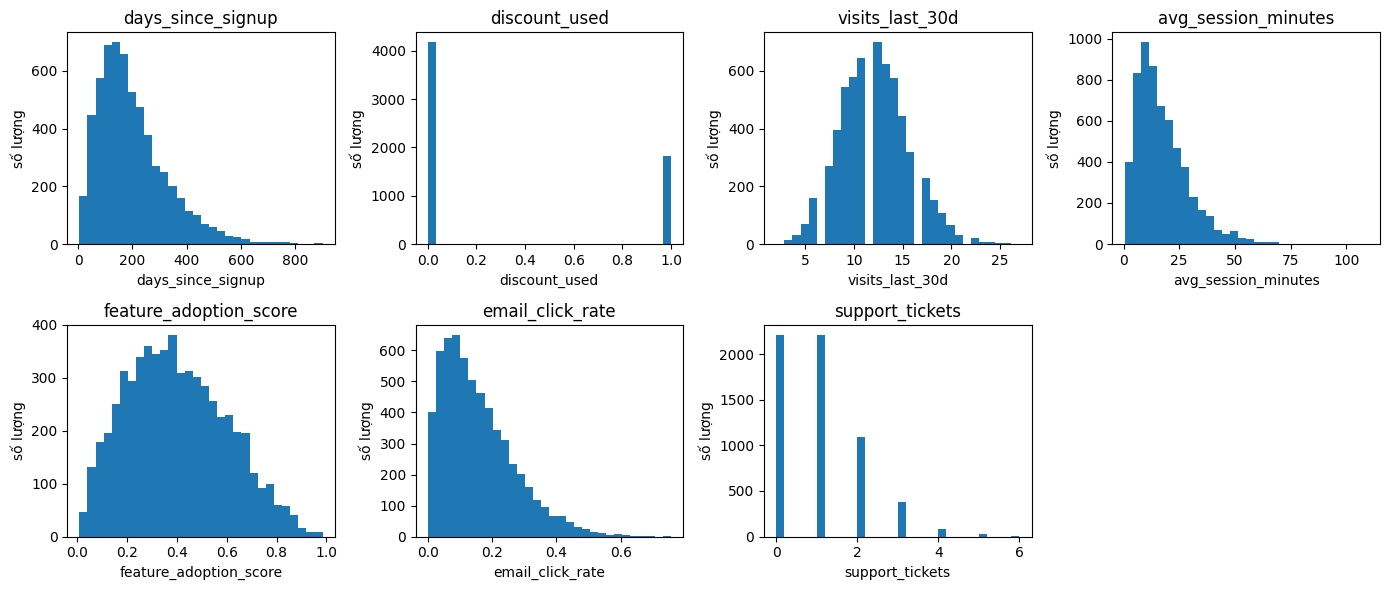

In [7]:

# Kiểm tra số lượng giá trị bị thiếu trong từng cột.
missing_count = df.isna().sum()

# Đặt tên cho Series kết quả là số_lượng_thiếu.
missing_count = missing_count.rename("số_lượng_thiếu")

# Chuyển Series thành DataFrame để dễ thêm cột phần trăm.
missing_report = missing_count.to_frame()

# Tính phần trăm giá trị thiếu trên tổng số dòng của DataFrame.
missing_percent = missing_report["số_lượng_thiếu"] / len(df) * 100

# Làm tròn phần trăm missing đến 2 chữ số thập phân.
missing_report["phần_trăm_thiếu"] = missing_percent.round(2)

# Hiển thị bảng báo cáo missing values.
display(missing_report)

# Tạo danh sách các cột số cần vẽ histogram.
numeric_cols = [
    # Số ngày kể từ khi đăng ký.
    "days_since_signup",
    # Biến nhị phân có dùng discount hay không.
    "discount_used",
    # Số lượt truy cập trong 30 ngày gần nhất.
    "visits_last_30d",
    # Thời lượng phiên trung bình.
    "avg_session_minutes",
    # Điểm sử dụng tính năng.
    "feature_adoption_score",
    # Tỷ lệ click email.
    "email_click_rate",
    # Số ticket hỗ trợ.
    "support_tickets",
]

# Tạo lưới biểu đồ gồm 2 hàng và 4 cột.
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

# Chuyển mảng axes 2 chiều thành 1 chiều để lặp dễ hơn.
axes = axes.ravel()

# Lặp qua từng cột số để vẽ histogram.
for index, column_name in enumerate(numeric_cols):
    # Vẽ histogram để quan sát phân phối dữ liệu của feature.
    axes[index].hist(df[column_name], bins=30)

    # Đặt tiêu đề biểu đồ là tên feature.
    axes[index].set_title(column_name)

    # Đặt nhãn trục x là tên feature.
    axes[index].set_xlabel(column_name)

    # Đặt nhãn trục y là số lượng quan sát.
    axes[index].set_ylabel("số lượng")

# Tắt ô biểu đồ cuối vì có 8 ô nhưng chỉ có 7 feature số.
axes[-1].axis("off")

# Tự động căn chỉnh khoảng cách giữa các biểu đồ.
plt.tight_layout()

# Hiển thị biểu đồ.
plt.show()

## 4. Chọn thước đo thành công

Với bài toán churn, accuracy không phải lúc nào cũng đủ tốt. Nếu lớp churn hiếm, một model luôn dự đoán “không churn” có thể có accuracy cao nhưng không hữu ích.

Ta sẽ dùng:

- **ROC AUC:** đo khả năng xếp hạng khách hàng churn cao hơn khách hàng không churn.
- **PR AUC:** hữu ích khi lớp dương hiếm.
- **Precision:** trong nhóm bị gắn cờ churn, bao nhiêu người thật sự churn.
- **Recall:** trong nhóm thật sự churn, model bắt được bao nhiêu người.
- **F1:** cân bằng giữa precision và recall.


## 5. Chia dữ liệu train / validation / test

Ta chia dữ liệu thành:

- **Train set:** dùng để model học.
- **Validation set:** dùng để chọn cấu hình model và threshold.
- **Test set:** chỉ dùng cuối cùng để đánh giá khách quan.

Thực hành quan trọng: mọi preprocessing cần học thống kê từ dữ liệu, ví dụ `Normalization.adapt()` hoặc `StringLookup.adapt()` (dùng để chuẩn hóa dữ liệu), chỉ được học từ training data.

- Normalization.adapt() → học mean/std của feature số → chuẩn hóa dữ liệu bằng $ x\_scaled = (x - mean) / std $
- StringLookup.adapt()  → học vocabulary của feature chuỗi → chuyển chuỗi thành số hoặc one-hot vector để model hiểu được. 


In [8]:
# Chọn tên cột target/label cần dự đoán.
target_col = "churned_next_30d"

# Tạo bảng feature X bằng cách bỏ cột target ra khỏi df.
X = df.drop(columns=[target_col])

# Tạo vector target y từ cột target.
y = df[target_col]

# Chia dữ liệu thành train_full 80% và test 20%.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    # Dữ liệu feature cần chia.
    X,
    # Target tương ứng với feature.
    y,
    # 20% dữ liệu được giữ lại làm test set.
    test_size=0.20,
    # Giữ tỷ lệ lớp 0/1 tương tự trong train và test.
    stratify=y,
    # Cố định seed để kết quả chia dữ liệu tái lập được.
    random_state=RANDOM_STATE,
)

# Chia train_full thành train 75% và validation 25% của train_full.
X_train, X_val, y_train, y_val = train_test_split(
    # Feature của tập train_full.
    X_train_full,
    # Target của tập train_full.
    y_train_full,
    # 25% của train_full sẽ trở thành validation set.
    test_size=0.25,
    # Giữ tỷ lệ lớp 0/1 tương tự trong train và validation.
    stratify=y_train_full,
    # Cố định seed để kết quả chia dữ liệu tái lập được.
    random_state=RANDOM_STATE,
)

# Tạo danh sách các feature dạng phân loại.
categorical_features = ["plan_type"]

# Tạo danh sách các feature số bằng cách lấy các cột không thuộc categorical_features.
numeric_features = [column for column in X.columns if column not in categorical_features]

# Tạo bảng tóm tắt kích thước và tỷ lệ lớp dương của các tập dữ liệu.
split_summary = pd.DataFrame({
    # Tên từng tập dữ liệu.
    "tập_dữ_liệu": ["train", "validation", "test"],

    # Số dòng trong từng tập dữ liệu.
    "số_dòng": [len(X_train), len(X_val), len(X_test)],

    # Vì y chỉ gồm 0/1, mean chính là tỷ lệ nhãn 1.
    "tỷ_lệ_lớp_dương": [y_train.mean(), y_val.mean(), y_test.mean()],
})

# Hiển thị bảng tóm tắt sau khi chia dữ liệu.
split_summary

,tập_dữ_liệu,số_dòng,tỷ_lệ_lớp_dương
0,train,3600,0.061111
1,validation,1200,0.060833
2,test,1200,0.060833


## 6. Hàm tiện ích cho Keras

Keras model trong notebook này nhận input dạng dictionary:

- `numeric_features`: một ma trận chứa toàn bộ feature số.
- `plan_type`: một vector chuỗi chứa loại gói dịch vụ.

Ta viết các hàm nhỏ để code train/evaluate dễ đọc hơn.


In [9]:

# Định nghĩa hàm chuyển DataFrame thành dictionary input cho Keras.
def make_model_inputs(X_data):
    """Mô tả hàm:
    Hàm này nhận vào một DataFrame feature.
    Hàm trả về dictionary có đúng tên input mà Keras model mong đợi.
    numeric_features được chuyển thành float32 để phù hợp với neural network.
    plan_type được chuyển thành chuỗi để đưa vào StringLookup layer.
    """
    # Tạo dictionary rỗng để chứa input cho model.
    model_inputs = {}

    # Lấy toàn bộ feature số thành một mảng NumPy.
    numeric_array = X_data[numeric_features].to_numpy()

    # Chuyển mảng feature số sang kiểu float32.
    numeric_array = numeric_array.astype("float32")

    # Gán mảng feature số vào key mà Keras Input sẽ dùng.
    model_inputs["numeric_features"] = numeric_array

    # Lấy cột plan_type và ép kiểu về string.
    plan_array = X_data["plan_type"].astype(str).to_numpy()

    # Gán plan_type vào dictionary input.
    model_inputs["plan_type"] = plan_array

    # Trả về dictionary input cho Keras model.
    return model_inputs


# Định nghĩa hàm tính class weight đơn giản cho bài toán mất cân bằng lớp.
def compute_class_weight(y_values):
    """Mô tả hàm:
    Hàm này nhận vào vector target gồm 0 và 1.
    Hàm trả về dictionary class_weight cho Keras model.fit().
    Lớp nào ít mẫu hơn sẽ có trọng số lớn hơn.
    Cách này giúp model chú ý hơn đến lớp thiểu số.
    """
    # Chuyển y_values thành mảng NumPy kiểu int.
    y_array = np.asarray(y_values).astype(int)

    # Đếm số lượng mẫu của từng lớp 0 và 1.
    counts = np.bincount(y_array)

    # Tính tổng số mẫu.
    total = counts.sum()

    # Tính trọng số cho lớp 0.
    weight_for_0 = total / (2 * counts[0])

    # Tính trọng số cho lớp 1.
    weight_for_1 = total / (2 * counts[1])

    # Tạo dictionary class weight theo format Keras yêu cầu.
    class_weight = {
        # Trọng số cho class 0.
        0: weight_for_0,
        # Trọng số cho class 1.
        1: weight_for_1,
    }

    # Trả về dictionary class weight.
    return class_weight


# Tính class weight dựa trên training set.
class_weight = compute_class_weight(y_train)

# Hiển thị class weight để xem lớp nào được ưu tiên hơn.
class_weight

{0: np.float64(0.5325443786982249), 1: np.float64(8.181818181818182)}

## 7. Tạo Keras model có preprocessing bên trong

Model gồm 2 phần:

1. **Preprocessing layers**
   - `Normalization`: học mean/variance của feature số bằng `adapt()`.
   - `StringLookup`: học vocabulary của `plan_type` bằng `adapt()`.

2. **Neural network layers**
   - `Dense`: học quan hệ giữa feature và target.
   - `Dropout` và L2: giảm overfitting nếu cần.

Vì preprocessing nằm trong model, khi lưu file `.keras`, logic tiền xử lý cũng được lưu cùng model.


In [10]:

# Định nghĩa hàm xây dựng Keras model cho bài toán churn.
def build_keras_churn_model(
    adapt_df,
    hidden_units=(64, 32),
    dropout_rate=0.0,
    l2_strength=0.0,
    learning_rate=0.001,
    model_name="keras_churn_model",
):
    """Mô tả hàm:
    Hàm này xây dựng một Keras model cho bài toán phân loại churn.
    adapt_df là dữ liệu dùng để adapt preprocessing layers.
    hidden_units quyết định số layer Dense và số neuron trong từng layer.
    dropout_rate quyết định tỷ lệ dropout để giảm overfitting.
    l2_strength quyết định mức L2 regularization.
    learning_rate quyết định tốc độ cập nhật trọng số khi train.
    Hàm trả về một Keras model đã compile sẵn.
    """
    # Tạo input cho toàn bộ feature số, shape là số lượng feature số.
    numeric_input = keras.Input(
        # Mỗi sample có len(numeric_features) giá trị số.
        shape=(len(numeric_features),),
        # Tên input phải khớp với dictionary trong make_model_inputs().
        name="numeric_features",
    )

    # Tạo layer Normalization cho feature số.
    normalizer = layers.Normalization(name="numeric_normalization")

    # Lấy dữ liệu số từ adapt_df và chuyển sang float32.
    numeric_adapt_data = adapt_df[numeric_features].to_numpy().astype("float32")

    # Chỉ adapt trên training data để tránh data leakage.
    normalizer.adapt(numeric_adapt_data)

    # Áp dụng layer Normalization lên numeric_input.
    normalized_numeric = normalizer(numeric_input)

    # Tạo input cho feature chuỗi plan_type.
    plan_input = keras.Input(
        # Mỗi sample có một chuỗi plan_type.
        shape=(),
        # Dữ liệu đầu vào là string.
        dtype=tf.string,
        # Tên input phải khớp với dictionary trong make_model_inputs().
        name="plan_type",
    )

    # Tạo layer StringLookup để mã hóa plan_type thành one-hot vector.
    plan_lookup = layers.StringLookup(
        # output_mode="one_hot" giúp biến category thành vector one-hot.
        output_mode="one_hot",
        # Đặt tên layer để model dễ đọc hơn.
        name="plan_type_lookup",
    )

    # Lấy dữ liệu plan_type từ adapt_df và chuyển thành chuỗi.
    plan_adapt_data = adapt_df["plan_type"].astype(str).to_numpy()

    # Chỉ adapt vocabulary trên training data để tránh data leakage.
    plan_lookup.adapt(plan_adapt_data)

    # Áp dụng lookup layer lên plan_input để có one-hot vector.
    encoded_plan = plan_lookup(plan_input)

    # Ghép feature số đã chuẩn hóa và plan_type đã one-hot lại thành một vector.
    x = layers.Concatenate(name="concatenate_features")([normalized_numeric, encoded_plan])

    # Tạo regularizer L2 nếu l2_strength lớn hơn 0.
    kernel_regularizer = regularizers.l2(l2_strength) if l2_strength > 0 else None

    # Lặp qua từng số neuron trong hidden_units để tạo các hidden Dense layer.
    for units in hidden_units:
        # Thêm Dense layer với activation ReLU.
        x = layers.Dense(
            # Số neuron của layer hiện tại.
            units,
            # ReLU giúp model học quan hệ phi tuyến.
            activation="relu",
            # L2 regularization giúp giảm overfitting nếu được bật.
            kernel_regularizer=kernel_regularizer,
        )(x)

        # Nếu dropout_rate > 0, thêm Dropout layer sau Dense layer.
        if dropout_rate > 0:
            # Dropout ngẫu nhiên tắt một phần neuron trong lúc train.
            x = layers.Dropout(dropout_rate)(x)

    # Tạo output layer có 1 neuron vì đây là bài toán binary classification.
    output = layers.Dense(
        # Một xác suất churn cho mỗi khách hàng.
        1,
        # Sigmoid đưa output về khoảng 0 đến 1.
        activation="sigmoid",
        # Đặt tên output để dễ đọc model summary.
        name="churn_probability",
    )(x)

    # Tạo Keras model từ input và output.
    model = keras.Model(
        # Model nhận hai input: numeric_features và plan_type.
        inputs={"numeric_features": numeric_input, "plan_type": plan_input},
        # Model trả về xác suất churn.
        outputs=output,
        # Đặt tên model.
        name=model_name,
    )

    # Tạo optimizer Adam với learning rate được truyền vào.
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    # Compile model với loss và metrics phù hợp cho binary classification.
    model.compile(
        # Adam là optimizer phổ biến và dễ dùng.
        optimizer=optimizer,
        # Binary crossentropy phù hợp với binary classification.
        loss="binary_crossentropy",
        # Theo dõi thêm nhiều metric trong lúc train.
        metrics=[
            # Accuracy dễ hiểu nhưng không phải metric chính.
            keras.metrics.BinaryAccuracy(name="accuracy"),
            # ROC AUC là metric chính trong demo này.
            keras.metrics.AUC(name="roc_auc"),
            # PR AUC hữu ích khi lớp dương không cân bằng.
            keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )

    # Trả về model đã compile.
    return model


# Tạo thử một model đơn giản để xem kiến trúc.
preview_model = build_keras_churn_model(
    # Chỉ adapt preprocessing trên training data.
    adapt_df=X_train,
    # Dùng một hidden layer nhỏ để mô hình dễ hiểu.
    hidden_units=(32,),
    # Không dùng dropout trong bản preview.
    dropout_rate=0.0,
    # Không dùng L2 trong bản preview.
    l2_strength=0.0,
    # Learning rate mặc định.
    learning_rate=0.001,
    # Đặt tên model preview.
    model_name="preview_churn_model",
)

# In summary để xem các layer của model.
preview_model.summary()

W0000 00:00:1779353631.772189   93438 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "preview_churn_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numeric_features    │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plan_type           │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_normalizat… │ (None, 7)         │         15 │ numeric_features… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plan_type_lookup    │ (None, 5)         │          0 │ plan_type[0][0]   │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_featur… │ (None, 12)        │          0 │ numeric_normaliz… │
│ (Concatenate)       │                   │            │ plan_type_lookup… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        416 │ concatenate_feat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ churn_probability   │ (None, 1)         │         33 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 464 (1.82 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 15 (64.00 B)

## 8. Baseline đơn giản

Trước khi dùng neural network, ta cần baseline.

Baseline giúp trả lời câu hỏi:

> Model ML có thật sự tốt hơn một quy tắc đơn giản không?

Ở đây, ta tạo một baseline thủ công: khách hàng có ít lượt truy cập, ít dùng tính năng, nhiều ticket hỗ trợ và dùng gói free sẽ có rủi ro churn cao hơn.


In [13]:

# Định nghĩa hàm chuẩn hóa min-max an toàn cho một mảng số.
def safe_minmax_scale(values):
    """Mô tả hàm:
    Hàm này đưa một mảng số về khoảng 0 đến 1 bằng min-max scaling.
    Nếu tất cả giá trị giống nhau, hàm trả về mảng toàn số 0 để tránh chia cho 0.
    Hàm này chỉ dùng cho baseline heuristic, không dùng cho Keras preprocessing.
    """
    # Chuyển input thành mảng NumPy kiểu float.
    values = np.asarray(values).astype(float)

    # Tìm giá trị nhỏ nhất trong mảng.
    min_value = values.min()

    # Tìm giá trị lớn nhất trong mảng.
    max_value = values.max()

    # Tính khoảng cách giữa max và min.
    value_range = max_value - min_value

    # Nếu range gần bằng 0, tức là dữ liệu gần như không thay đổi.
    if value_range < 1e-8:
        # Trả về mảng toàn số 0 có cùng shape.
        return np.zeros_like(values)

    # Áp dụng công thức min-max scaling.
    scaled_values = (values - min_value) / value_range

    # Trả về mảng đã scale về 0 đến 1.
    return scaled_values


# Định nghĩa baseline dựa trên quy tắc thủ công.
def heuristic_churn_score(X_data):
    """Mô tả hàm:
    Hàm này tạo điểm rủi ro churn bằng một quy tắc đơn giản, không học từ dữ liệu.
    Điểm rủi ro cao hơn nếu khách hàng ít truy cập, ít dùng tính năng, nhiều ticket hỗ trợ hoặc dùng gói free.
    Kết quả được chuẩn hóa về khoảng 0 đến 1 để xem như xác suất gần đúng.
    """
    # Tính điểm rủi ro do ít truy cập: visits càng thấp thì rủi ro càng cao.
    low_visit_risk = safe_minmax_scale(-X_data["visits_last_30d"])

    # Tính điểm rủi ro do ít dùng tính năng: adoption càng thấp thì rủi ro càng cao.
    low_adoption_risk = safe_minmax_scale(-X_data["feature_adoption_score"])

    # Tính điểm rủi ro do nhiều ticket hỗ trợ.
    ticket_risk = safe_minmax_scale(X_data["support_tickets"])

    # Tạo điểm cộng nếu khách hàng dùng gói free.
    free_plan_risk = (X_data["plan_type"] == "free").astype(float)

    # Kết hợp các tín hiệu rủi ro bằng trọng số thủ công.
    risk_score = (
        # Ít truy cập là tín hiệu mạnh.
        0.35 * low_visit_risk
        # Ít dùng tính năng cũng là tín hiệu mạnh.
        + 0.35 * low_adoption_risk
        # Nhiều ticket là tín hiệu vừa phải.
        + 0.20 * ticket_risk
        # Gói free là tín hiệu bổ sung.
        + 0.10 * free_plan_risk
    )

    # Đảm bảo điểm nằm trong khoảng 0 đến 1.
    risk_score = np.clip(risk_score, 0, 1)

    # Trả về điểm rủi ro.
    return risk_score


# Định nghĩa hàm đánh giá xác suất dự đoán bằng nhiều metric.
def evaluate_probabilities(y_true, y_proba, threshold=0.50, label="model"):
    """Mô tả hàm:
    Hàm này nhận y_true và xác suất dự đoán y_proba.
    Hàm chuyển xác suất thành nhãn 0/1 bằng threshold.
    Hàm trả về dictionary gồm ROC AUC, PR AUC, accuracy, precision, recall và F1.
    """
    # Chuyển y_true thành mảng số nguyên 0/1.
    y_true_array = np.asarray(y_true).astype(int)

    # Chuyển y_proba thành mảng số thực 1 chiều.
    y_proba_array = np.asarray(y_proba).reshape(-1)

    # Chuyển xác suất thành nhãn dự đoán dựa trên threshold.
    y_pred_array = (y_proba_array >= threshold).astype(int)

    # Tạo dictionary chứa metric đánh giá.
    metrics = {
        # Tên model hoặc thí nghiệm.
        "model": label,
        # Threshold dùng để đổi xác suất thành nhãn.
        "threshold": threshold,
        # ROC AUC đánh giá khả năng xếp hạng.
        "roc_auc": roc_auc_score(y_true_array, y_proba_array),
        # PR AUC hữu ích khi lớp dương hiếm.
        "pr_auc": average_precision_score(y_true_array, y_proba_array),
        # Accuracy là tỷ lệ dự đoán đúng.
        "accuracy": accuracy_score(y_true_array, y_pred_array),
        # Precision là độ chính xác trong nhóm bị dự đoán churn.
        "precision": precision_score(y_true_array, y_pred_array, zero_division=0),
        # Recall là tỷ lệ bắt được khách hàng thật sự churn.
        "recall": recall_score(y_true_array, y_pred_array, zero_division=0),
        # F1 cân bằng giữa precision và recall.
        "f1": f1_score(y_true_array, y_pred_array, zero_division=0),
        # Tỷ lệ khách hàng bị gắn cờ rủi ro cao.
        "flag_rate": y_pred_array.mean(),
    }

    # Trả về dictionary metric.
    return metrics


# Tính xác suất baseline trên validation set.
baseline_val_proba = heuristic_churn_score(X_val)

# Đánh giá baseline trên validation set.
baseline_metrics = evaluate_probabilities(
    # Target thật của validation set.
    y_true=y_val,
    # Điểm rủi ro baseline.
    y_proba=baseline_val_proba,
    # Dùng threshold mặc định 0.5.
    threshold=0.50,
    # Đặt tên baseline.
    label="baseline_thủ_công",
)

# Hiển thị metric baseline dưới dạng DataFrame.
pd.DataFrame([baseline_metrics]).round(3)

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,flag_rate
0,baseline_thủ_công,0.5,0.625,0.095,0.606,0.085,0.562,0.148,0.402


## 9. Huấn luyện mô hình Keras đơn giản

Bây giờ ta huấn luyện một neural network nhỏ.

Mục tiêu của bước này:

- Kiểm tra model Keras có học được tín hiệu từ dữ liệu không.
- So sánh với baseline thủ công.
- Chưa vội tối ưu mạnh.


In [14]:
# Định nghĩa hàm lấy xác suất dự đoán từ Keras model.
def predict_proba_keras(model, X_data):
    """Mô tả hàm:
    Hàm này nhận vào một Keras model và DataFrame feature.
    Hàm chuyển DataFrame thành input đúng format bằng make_model_inputs().
    Hàm trả về xác suất churn dạng mảng 1 chiều.
    """
    # Chuyển DataFrame thành dictionary input cho Keras model.
    model_inputs = make_model_inputs(X_data)

    # Gọi model.predict() để lấy xác suất dự đoán.
    probabilities = model.predict(model_inputs, verbose=0)

    # Chuyển output shape (n, 1) thành shape (n,).
    probabilities = probabilities.reshape(-1)

    # Trả về xác suất churn.
    return probabilities


# Định nghĩa hàm đánh giá Keras model trên một dataset.
def evaluate_keras_model(model, X_data, y_data, threshold=0.50, label="keras_model"):
    """Mô tả hàm:
    Hàm này nhận vào Keras model, feature X và target y.
    Hàm dự đoán xác suất churn bằng predict_proba_keras().
    Hàm gọi evaluate_probabilities() để tính metric.
    """
    # Lấy xác suất dự đoán từ Keras model.
    probabilities = predict_proba_keras(model, X_data)

    # Tính các metric đánh giá từ xác suất dự đoán.
    metrics = evaluate_probabilities(
        # Target thật.
        y_true=y_data,
        # Xác suất dự đoán churn.
        y_proba=probabilities,
        # Threshold để đổi xác suất thành nhãn 0/1.
        threshold=threshold,
        # Tên model/thí nghiệm.
        label=label,
    )

    # Trả về dictionary metric.
    return metrics


# Xóa graph/model cũ trong Keras để tránh rác bộ nhớ khi chạy lại cell.
keras.backend.clear_session()

# Đặt lại seed để kết quả huấn luyện dễ tái lập hơn.
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Tạo model Keras đơn giản.
simple_model = build_keras_churn_model(
    # Chỉ adapt preprocessing trên training data.
    adapt_df=X_train,
    # Dùng một hidden layer nhỏ.
    hidden_units=(32,),
    # Chưa dùng dropout.
    dropout_rate=0.0,
    # Chưa dùng L2.
    l2_strength=0.0,
    # Learning rate dễ dùng.
    learning_rate=0.001,
    # Đặt tên model.
    model_name="simple_keras_churn_model",
)

# Tạo EarlyStopping để dừng sớm khi validation ROC AUC không cải thiện.
early_stopping = keras.callbacks.EarlyStopping(
    # Theo dõi validation ROC AUC.
    monitor="val_roc_auc",
    # Vì ROC AUC càng lớn càng tốt, mode là max.
    mode="max",
    # Cho phép chờ 8 epoch không cải thiện trước khi dừng.
    patience=8,
    # Khôi phục trọng số tốt nhất trên validation set.
    restore_best_weights=True,
)

# Huấn luyện model đơn giản.
simple_history = simple_model.fit(
    # Input training đã chuyển sang dictionary cho Keras.
    make_model_inputs(X_train),
    # Target training chuyển sang float32.
    y_train.to_numpy().astype("float32"),
    # Validation data để theo dõi khả năng tổng quát hóa.
    validation_data=(make_model_inputs(X_val), y_val.to_numpy().astype("float32")),
    # Số epoch tối đa.
    epochs=60,
    # Kích thước batch.
    batch_size=128,
    # Class weight giúp xử lý mất cân bằng lớp.
    class_weight=class_weight,
    # Callback dừng sớm.
    callbacks=[early_stopping],
    # verbose=1 để thấy tiến trình train.
    verbose=1,
)

# Đánh giá model đơn giản trên validation set.
simple_metrics = evaluate_keras_model(
    # Model đã train.
    simple_model,
    # Feature validation.
    X_val,
    # Target validation.
    y_val,
    # Threshold mặc định 0.5.
    threshold=0.50,
    # Tên model trong bảng kết quả.
    label="keras_đơn_giản_validation",
)

# So sánh baseline và model Keras đơn giản.
pd.DataFrame([baseline_metrics, simple_metrics]).round(3)

Epoch 1/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.2997 - loss: 0.6859 - pr_auc: 0.0904 - roc_auc: 0.6043 - val_accuracy: 0.4083 - val_loss: 0.7556 - val_pr_auc: 0.0819 - val_roc_auc: 0.5856
Epoch 2/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4706 - loss: 0.6635 - pr_auc: 0.1098 - roc_auc: 0.6445 - val_accuracy: 0.5233 - val_loss: 0.7021 - val_pr_auc: 0.0906 - val_roc_auc: 0.6125
Epoch 3/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5328 - loss: 0.6529 - pr_auc: 0.1224 - roc_auc: 0.6632 - val_accuracy: 0.5608 - val_loss: 0.6798 - val_pr_auc: 0.0990 - val_roc_auc: 0.6284
Epoch 4/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5617 - loss: 0.6465 - pr_auc: 0.1292 - roc_auc: 0.6740 - val_accuracy: 0.5817 - val_loss: 0.6691 - val_pr_auc: 0.1036 - val_roc_auc: 0.6356
Epoch 5/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5761 - loss: 0.6422 - pr_auc: 0.1333 - roc_auc: 0.6807 - val_accuracy: 0.5892 - val_loss: 0.6629 - val_pr_auc: 0.104

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,flag_rate
0,baseline_thủ_công,0.5,0.625,0.095,0.606,0.085,0.562,0.148,0.402
1,keras_đơn_giản_validation,0.5,0.658,0.112,0.636,0.101,0.630,0.174,0.380


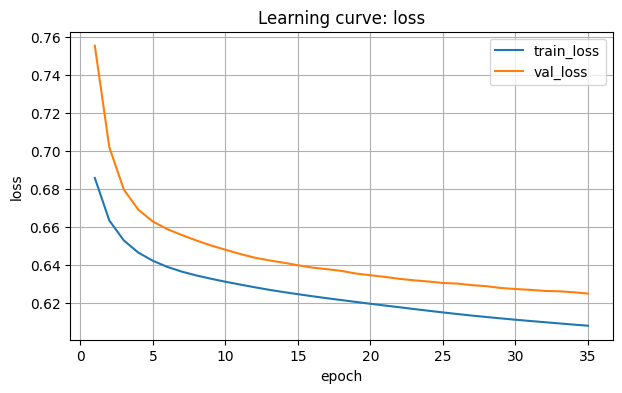

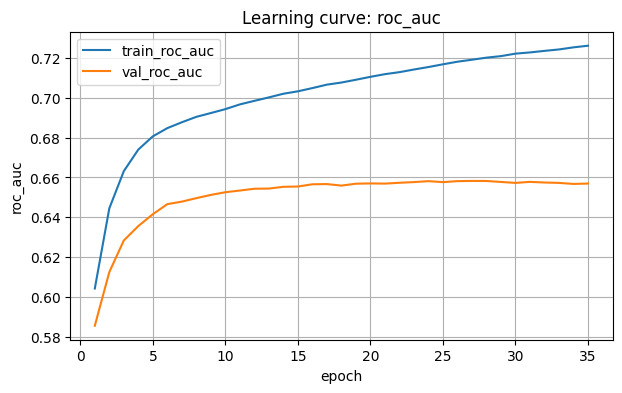

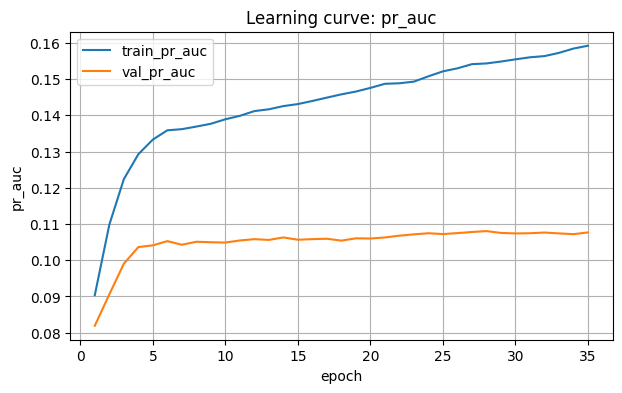

,accuracy,loss,pr_auc,roc_auc,val_accuracy,val_loss,val_pr_auc,val_roc_auc,epoch
30,0.646,0.610,0.156,0.723,0.636,0.627,0.107,0.658,31
31,0.647,0.610,0.156,0.724,0.637,0.626,0.108,0.657,32
32,0.648,0.609,0.157,0.724,0.637,0.626,0.107,0.657,33
33,0.649,0.609,0.158,0.725,0.638,0.626,0.107,0.657,34
34,0.649,0.608,0.159,0.726,0.640,0.625,0.108,0.657,35


In [15]:

# Định nghĩa hàm vẽ learning curves từ Keras History object.
def plot_training_history(history, metric_names=("loss", "roc_auc")):
    """Mô tả hàm:
    Hàm này nhận Keras History object sau khi model.fit().
    Hàm chuyển lịch sử train thành DataFrame.
    Hàm vẽ đường train và validation cho các metric được chọn.
    """
    # Chuyển history.history dictionary thành DataFrame.
    history_df = pd.DataFrame(history.history)

    # Tạo cột epoch bắt đầu từ 1 để dễ đọc biểu đồ.
    history_df["epoch"] = np.arange(1, len(history_df) + 1)

    # Lặp qua từng metric cần vẽ.
    for metric_name in metric_names:
        # Tạo một figure riêng cho từng metric.
        plt.figure(figsize=(7, 4))

        # Vẽ đường metric trên training set.
        plt.plot(history_df["epoch"], history_df[metric_name], label=f"train_{metric_name}")

        # Tạo tên cột validation metric tương ứng.
        validation_metric_name = f"val_{metric_name}"

        # Nếu validation metric tồn tại trong history, vẽ thêm đường validation.
        if validation_metric_name in history_df.columns:
            # Vẽ đường metric trên validation set.
            plt.plot(history_df["epoch"], history_df[validation_metric_name], label=validation_metric_name)

        # Đặt tiêu đề biểu đồ.
        plt.title(f"Learning curve: {metric_name}")

        # Đặt nhãn trục x.
        plt.xlabel("epoch")

        # Đặt nhãn trục y.
        plt.ylabel(metric_name)

        # Hiển thị chú thích các đường.
        plt.legend()

        # Hiển thị lưới nhẹ để dễ đọc.
        plt.grid(True)

        # Hiển thị biểu đồ.
        plt.show()

    # Trả về DataFrame lịch sử để có thể xem bằng bảng.
    return history_df


# Vẽ learning curves cho model đơn giản.
simple_history_df = plot_training_history(simple_history, metric_names=("loss", "roc_auc", "pr_auc"))

# Xem 5 epoch cuối cùng.
simple_history_df.tail().round(3)


## 10. Tăng capacity để thấy overfitting

Một bước quan trọng trong workflow là kiểm tra model có đủ khả năng học không.

Ta cố tình tạo model lớn và train trên một tập train nhỏ. Nếu training score cao nhưng validation score kém hơn, đó là dấu hiệu **overfitting**.


In [16]:

# Lấy một phần nhỏ training set để dễ quan sát overfitting.
X_train_small = X_train.sample(n=700, random_state=RANDOM_STATE)

# Lấy target tương ứng với các index của X_train_small.
y_train_small = y_train.loc[X_train_small.index]

# Tính class weight cho tập train nhỏ.
small_class_weight = compute_class_weight(y_train_small)

# Xóa graph/model cũ trong Keras.
keras.backend.clear_session()

# Đặt lại seed để kết quả dễ tái lập.
tf.keras.utils.set_random_seed(RANDOM_STATE + 1)

# Tạo model lớn hơn để dễ overfit.
overfit_model = build_keras_churn_model(
    # Chỉ adapt preprocessing trên tập train nhỏ.
    adapt_df=X_train_small,
    # Model lớn hơn với nhiều neuron hơn.
    hidden_units=(256, 128, 64),
    # Không dùng dropout để model dễ overfit.
    dropout_rate=0.0,
    # Không dùng L2 để model dễ overfit.
    l2_strength=0.0,
    # Learning rate mặc định.
    learning_rate=0.001,
    # Đặt tên model.
    model_name="overfit_demo_model",
)

# Train model lớn trên tập train nhỏ.
overfit_history = overfit_model.fit(
    # Input train nhỏ.
    make_model_inputs(X_train_small),
    # Target train nhỏ.
    y_train_small.to_numpy().astype("float32"),
    # Validation vẫn dùng X_val đầy đủ.
    validation_data=(make_model_inputs(X_val), y_val.to_numpy().astype("float32")),
    # Cho nhiều epoch để model có cơ hội overfit.
    epochs=100,
    # Batch size nhỏ hơn.
    batch_size=32,
    # Dùng class weight của tập nhỏ.
    class_weight=small_class_weight,
    # Không in chi tiết từng epoch để output gọn.
    verbose=0,
)

# Đánh giá overfit model trên train nhỏ.
overfit_train_metrics = evaluate_keras_model(
    # Model lớn đã train.
    overfit_model,
    # Feature train nhỏ.
    X_train_small,
    # Target train nhỏ.
    y_train_small,
    # Threshold mặc định.
    threshold=0.50,
    # Tên kết quả.
    label="model_lớn_train_nhỏ",
)

# Đánh giá overfit model trên validation set.
overfit_val_metrics = evaluate_keras_model(
    # Model lớn đã train.
    overfit_model,
    # Feature validation.
    X_val,
    # Target validation.
    y_val,
    # Threshold mặc định.
    threshold=0.50,
    # Tên kết quả.
    label="model_lớn_validation",
)

# Hiển thị train vs validation để nhìn dấu hiệu overfitting.
pd.DataFrame([overfit_train_metrics, overfit_val_metrics]).round(3)

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,flag_rate
0,model_lớn_train_nhỏ,0.5,1.000,1.000,1.000,1.000,1.000,1.000,0.057
1,model_lớn_validation,0.5,0.552,0.074,0.917,0.091,0.041,0.057,0.028


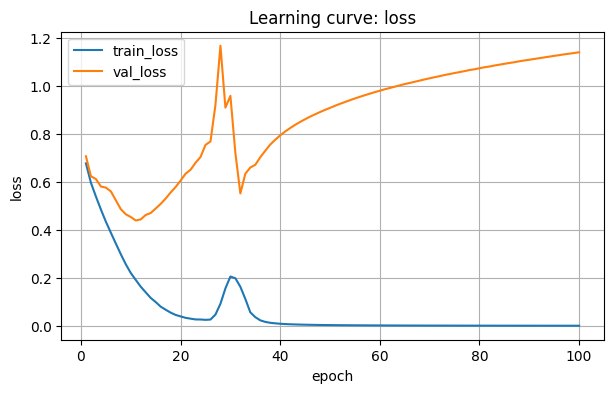

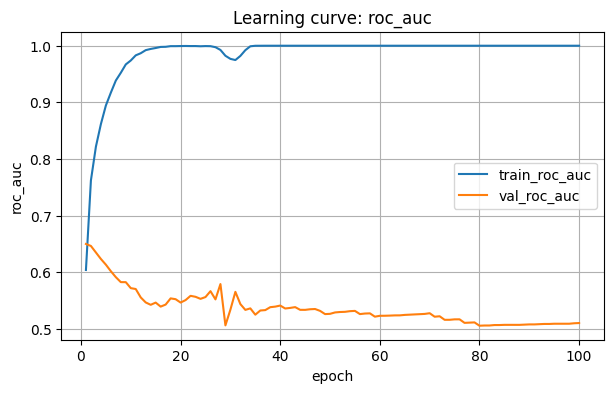

,accuracy,loss,pr_auc,roc_auc,val_accuracy,val_loss,val_pr_auc,val_roc_auc,epoch
95,1.0,0.0,1.0,1.0,0.917,1.127,0.065,0.509,96
96,1.0,0.0,1.0,1.0,0.916,1.131,0.065,0.509,97
97,1.0,0.0,1.0,1.0,0.916,1.133,0.065,0.509,98
98,1.0,0.0,1.0,1.0,0.916,1.136,0.065,0.510,99
99,1.0,0.0,1.0,1.0,0.917,1.139,0.065,0.510,100


In [17]:

# Vẽ learning curves của model lớn.
overfit_history_df = plot_training_history(overfit_history, metric_names=("loss", "roc_auc"))

# Hiển thị vài epoch cuối để xem train/validation metric.
overfit_history_df.tail().round(3)


## 11. Regularize và chọn model tốt bằng validation set

Sau khi biết model có thể overfit, ta thử vài cấu hình có regularization.

Các kỹ thuật dùng ở đây:

- `Dropout`: giảm phụ thuộc quá mức vào một nhóm neuron.
- L2 regularization: phạt trọng số quá lớn.
- `EarlyStopping`: dừng train khi validation ROC AUC không cải thiện.

Ta chọn model có validation ROC AUC tốt nhất.


In [18]:

# Tạo danh sách cấu hình ứng viên để thử.
candidate_configs = [
    # Model nhỏ, không regularization.
    {"hidden_units": (32,), "dropout_rate": 0.0, "l2_strength": 0.0, "learning_rate": 0.001},
    # Model vừa, có dropout và L2 nhẹ.
    {"hidden_units": (64, 32), "dropout_rate": 0.20, "l2_strength": 0.0001, "learning_rate": 0.001},
    # Model lớn hơn, dropout cao hơn.
    {"hidden_units": (128, 64), "dropout_rate": 0.30, "l2_strength": 0.0001, "learning_rate": 0.0008},
]

# Tạo list rỗng để lưu metric của từng cấu hình.
validation_rows = []

# Tạo list rỗng để lưu model và history của từng cấu hình.
trained_candidates = []

# Lặp qua từng cấu hình ứng viên.
for candidate_number, config in enumerate(candidate_configs, start=1):
    # Xóa graph/model cũ trước khi build model mới.
    keras.backend.clear_session()

    # Đặt seed khác nhau một chút cho từng ứng viên.
    tf.keras.utils.set_random_seed(RANDOM_STATE + candidate_number)

    # Build model theo cấu hình hiện tại.
    candidate_model = build_keras_churn_model(
        # Chỉ adapt preprocessing trên training set.
        adapt_df=X_train,
        # Số neuron/layer của model.
        hidden_units=config["hidden_units"],
        # Tỷ lệ dropout.
        dropout_rate=config["dropout_rate"],
        # Độ mạnh L2.
        l2_strength=config["l2_strength"],
        # Learning rate.
        learning_rate=config["learning_rate"],
        # Tên model.
        model_name=f"candidate_model_{candidate_number}",
    )

    # Tạo EarlyStopping cho ứng viên hiện tại.
    callback = keras.callbacks.EarlyStopping(
        # Theo dõi validation ROC AUC.
        monitor="val_roc_auc",
        # ROC AUC càng lớn càng tốt.
        mode="max",
        # Chờ 8 epoch không cải thiện trước khi dừng.
        patience=8,
        # Khôi phục trọng số tốt nhất.
        restore_best_weights=True,
    )

    # Train model ứng viên.
    candidate_history = candidate_model.fit(
        # Input train.
        make_model_inputs(X_train),
        # Target train.
        y_train.to_numpy().astype("float32"),
        # Validation data.
        validation_data=(make_model_inputs(X_val), y_val.to_numpy().astype("float32")),
        # Số epoch tối đa.
        epochs=80,
        # Batch size.
        batch_size=128,
        # Class weight.
        class_weight=class_weight,
        # Callback EarlyStopping.
        callbacks=[callback],
        # Không in log chi tiết để bảng kết quả dễ đọc.
        verbose=0,
    )

    # Đánh giá model ứng viên trên validation set.
    candidate_metrics = evaluate_keras_model(
        # Model ứng viên đã train.
        candidate_model,
        # Feature validation.
        X_val,
        # Target validation.
        y_val,
        # Threshold mặc định 0.5.
        threshold=0.50,
        # Tên ứng viên.
        label=f"candidate_{candidate_number}",
    )

    # Thêm số thứ tự ứng viên vào metric.
    candidate_metrics["candidate_number"] = candidate_number

    # Thêm cấu hình hidden_units vào metric để dễ xem.
    candidate_metrics["hidden_units"] = str(config["hidden_units"])

    # Thêm dropout_rate vào metric.
    candidate_metrics["dropout_rate"] = config["dropout_rate"]

    # Thêm l2_strength vào metric.
    candidate_metrics["l2_strength"] = config["l2_strength"]

    # Lấy epoch tốt nhất tương ứng với số epoch đã train.
    candidate_metrics["epochs_trained"] = len(candidate_history.history["loss"])

    # Lưu metric vào list.
    validation_rows.append(candidate_metrics)

    # Lưu model, history, config và metric để dùng lại sau.
    trained_candidates.append((candidate_model, candidate_history, config, candidate_metrics))

# Chuyển các metric validation thành DataFrame.
validation_results = pd.DataFrame(validation_rows)

# Sắp xếp ứng viên theo ROC AUC validation giảm dần.
validation_results = validation_results.sort_values("roc_auc", ascending=False)

# Hiển thị bảng kết quả validation.
validation_results.round(3)


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,flag_rate,candidate_number,hidden_units,dropout_rate,l2_strength,epochs_trained
1,candidate_2,0.5,0.653,0.120,0.646,0.093,0.548,0.158,0.360,2,"(64, 32)",0.2,0.0,14
0,candidate_1,0.5,0.653,0.127,0.642,0.095,0.575,0.164,0.367,1,"(32,)",0.0,0.0,23
2,candidate_3,0.5,0.646,0.118,0.599,0.089,0.603,0.155,0.413,3,"(128, 64)",0.3,0.0,11


Cấu hình tốt nhất trên validation set:
{'hidden_units': (64, 32), 'dropout_rate': 0.2, 'l2_strength': 0.0001, 'learning_rate': 0.001}


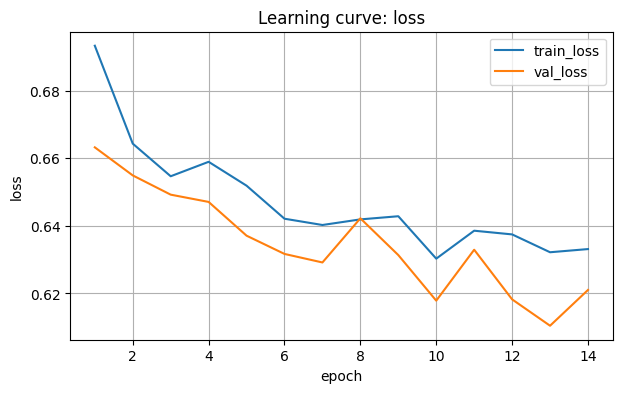

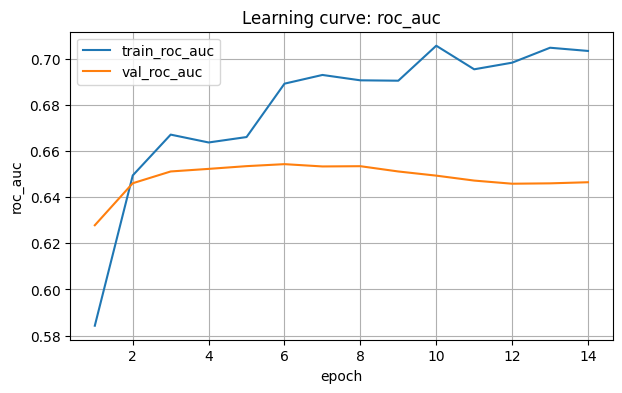

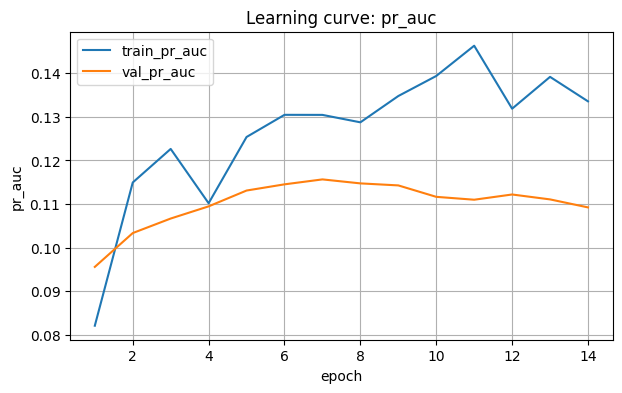

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,flag_rate,candidate_number,hidden_units,dropout_rate,l2_strength,epochs_trained
0,baseline_thủ_công,0.5,0.625,0.095,0.606,0.085,0.562,0.148,0.402,NaN,NaN,NaN,NaN,NaN
1,keras_đơn_giản_validation,0.5,0.658,0.112,0.636,0.101,0.630,0.174,0.380,NaN,NaN,NaN,NaN,NaN
2,candidate_2,0.5,0.653,0.120,0.646,0.093,0.548,0.158,0.360,2.0,"(64, 32)",0.2,0.0,14.0


In [22]:

# Lấy số thứ tự của ứng viên tốt nhất từ bảng validation_results.
best_candidate_number = int(validation_results.iloc[0]["candidate_number"])

# Vì list bắt đầu từ index 0, ta lấy best_candidate_number - 1.
best_candidate_index = best_candidate_number - 1

# Lấy model, history, config và metric tốt nhất.
best_model, best_history, best_config, best_metrics = trained_candidates[best_candidate_index]

# In cấu hình tốt nhất.
print("Cấu hình tốt nhất trên validation set:")

# In dictionary cấu hình tốt nhất.
print(best_config)

# Tạo bảng so sánh các mốc quan trọng.
comparison_table = pd.DataFrame([
    # Baseline thủ công.
    baseline_metrics,
    # Model Keras đơn giản.
    simple_metrics,
    # Model tốt nhất sau regularization.
    best_metrics,
])

# Vẽ learning curves của model tốt nhất.
plot_training_history(best_history, metric_names=("loss", "roc_auc", "pr_auc"));

# Hiển thị bảng so sánh.
comparison_table.round(3)

## 12. Đánh giá cuối cùng trên test set

Sau khi chọn cấu hình bằng validation set, ta train lại model cuối cùng trên `train + validation`.

Sau đó, ta đánh giá trên test set đúng một lần.

Trong dự án thật, không nên dùng test set để chọn model hoặc threshold, vì như vậy test set sẽ mất vai trò đánh giá khách quan.


In [23]:

# Lấy số epoch hợp lý từ history của model tốt nhất.
final_epochs = len(best_history.history["loss"])

# Tính class weight trên train_full, tức train + validation.
full_class_weight = compute_class_weight(y_train_full)

# Xóa graph/model cũ trước khi build final model.
keras.backend.clear_session()

# Đặt lại seed để kết quả dễ tái lập.
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Build final model với cấu hình tốt nhất.
final_model = build_keras_churn_model(
    # Final model được adapt preprocessing trên train_full.
    adapt_df=X_train_full,
    # Dùng hidden_units tốt nhất.
    hidden_units=best_config["hidden_units"],
    # Dùng dropout_rate tốt nhất.
    dropout_rate=best_config["dropout_rate"],
    # Dùng l2_strength tốt nhất.
    l2_strength=best_config["l2_strength"],
    # Dùng learning_rate tốt nhất.
    learning_rate=best_config["learning_rate"],
    # Đặt tên final model.
    model_name="final_churn_inference_model",
)

# Train final model trên train_full.
final_history = final_model.fit(
    # Input train_full.
    make_model_inputs(X_train_full),
    # Target train_full.
    y_train_full.to_numpy().astype("float32"),
    # Số epoch lấy theo model tốt nhất.
    epochs=final_epochs,
    # Batch size.
    batch_size=128,
    # Class weight trên train_full.
    class_weight=full_class_weight,
    # In log train.
    verbose=1,
)

# Đánh giá final model trên test set.
test_metrics = evaluate_keras_model(
    # Final model.
    final_model,
    # Feature test.
    X_test,
    # Target test.
    y_test,
    # Threshold mặc định 0.5.
    threshold=0.50,
    # Tên kết quả test.
    label="final_model_test",
)

# Tạo bảng tổng hợp kết quả cuối.
final_results = pd.DataFrame([
    # Baseline validation.
    baseline_metrics,
    # Model đơn giản validation.
    simple_metrics,
    # Best model validation.
    best_metrics,
    # Final model test.
    test_metrics,
])

# Hiển thị bảng kết quả cuối.
final_results.round(3)


Epoch 1/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5683 - loss: 0.6931 - pr_auc: 0.0817 - roc_auc: 0.5671
Epoch 2/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5996 - loss: 0.6678 - pr_auc: 0.1099 - roc_auc: 0.6465
Epoch 3/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6131 - loss: 0.6600 - pr_auc: 0.1117 - roc_auc: 0.6645
Epoch 4/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6125 - loss: 0.6602 - pr_auc: 0.1244 - roc_auc: 0.6548
Epoch 5/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6283 - loss: 0.6516 - pr_auc: 0.1170 - roc_auc: 0.6712
Epoch 6/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6288 - loss: 0.6459 - pr_auc: 0.1236 - roc_auc: 0.6811
Epoch 7/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6452 - loss: 0.6411 - pr_auc: 0.1308 - roc_auc: 0.6915
Epoch 8/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6433 - loss: 0.6448 - pr_auc: 0.1250 - roc_auc: 0.6891
Epoch 9/14
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/ste

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,flag_rate,candidate_number,hidden_units,dropout_rate,l2_strength,epochs_trained
0,baseline_thủ_công,0.5,0.625,0.095,0.606,0.085,0.562,0.148,0.402,NaN,NaN,NaN,NaN,NaN
1,keras_đơn_giản_validation,0.5,0.658,0.112,0.636,0.101,0.630,0.174,0.380,NaN,NaN,NaN,NaN,NaN
2,candidate_2,0.5,0.653,0.120,0.646,0.093,0.548,0.158,0.360,2.0,"(64, 32)",0.2,0.0,14.0
3,final_model_test,0.5,0.658,0.121,0.630,0.098,0.616,0.169,0.384,NaN,NaN,NaN,NaN,NaN


## 13. Chọn threshold vận hành

Keras model trả về xác suất churn.

Trong production, ta cần chọn một threshold để chuyển xác suất thành quyết định:

- Nếu xác suất >= threshold → gắn cờ rủi ro cao.
- Nếu xác suất < threshold → không gắn cờ.

Threshold nên được chọn trên validation set, dựa trên mục tiêu kinh doanh.


In [24]:

# Tạo list rỗng để lưu kết quả ở từng threshold.
threshold_rows = []

# Lấy xác suất dự đoán của best_model trên validation set.
validation_probabilities = predict_proba_keras(best_model, X_val)

# Duyệt qua một số threshold phổ biến.
for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    # Đổi xác suất thành nhãn dự đoán theo threshold hiện tại.
    validation_predictions = (validation_probabilities >= threshold).astype(int)

    # Tính metric cho threshold hiện tại và thêm vào list.
    threshold_rows.append({
        # Lưu threshold hiện tại.
        "threshold": threshold,
        # Tính precision.
        "precision": precision_score(y_val, validation_predictions, zero_division=0),
        # Tính recall.
        "recall": recall_score(y_val, validation_predictions, zero_division=0),
        # Tính F1.
        "f1": f1_score(y_val, validation_predictions, zero_division=0),
        # Tính tỷ lệ khách hàng bị gắn cờ rủi ro cao.
        "tỷ_lệ_bị_gắn_cờ": validation_predictions.mean(),
    })

# Chuyển kết quả threshold thành DataFrame.
threshold_table = pd.DataFrame(threshold_rows)

# Chọn threshold có F1 cao nhất trên validation set.
selected_threshold = threshold_table.sort_values("f1", ascending=False).iloc[0]["threshold"]

# Chuyển selected_threshold thành float Python thông thường.
selected_threshold = float(selected_threshold)

# In threshold được chọn.
print("Threshold được chọn theo F1 trên validation set:", selected_threshold)

# Hiển thị bảng threshold.
threshold_table.round(3)


Threshold được chọn theo F1 trên validation set: 0.6


,threshold,precision,recall,f1,tỷ_lệ_bị_gắn_cờ
0,0.2,0.062,1.000,0.118,0.974
1,0.3,0.069,0.945,0.128,0.838
2,0.4,0.080,0.767,0.145,0.585
3,0.5,0.093,0.548,0.158,0.360
4,0.6,0.124,0.342,0.182,0.168
5,0.7,0.175,0.137,0.154,0.048


## 14. Lưu inference model

Trong production, ta không triển khai notebook. Ta triển khai một **inference artifact**.

Ở đây, ta lưu:

- `churn_inference_model.keras`: model Keras gồm cả preprocessing và neural network.
- `churn_threshold.json`: threshold vận hành.


In [25]:

# Tạo đường dẫn lưu Keras model.
model_path = Path("churn_inference_model.keras")

# Tạo đường dẫn lưu threshold.
threshold_path = Path("churn_threshold.json")

# Lưu final model ra file .keras.
final_model.save(model_path)

# Tạo dictionary chứa threshold đã chọn.
threshold_dict = {"threshold": selected_threshold}

# Ghi threshold ra file JSON.
threshold_path.write_text(json.dumps(threshold_dict, indent=2), encoding="utf-8")

# In đường dẫn tuyệt đối của model đã lưu.
print("Đã lưu Keras inference model tại:", model_path.resolve())

# In đường dẫn tuyệt đối của threshold đã lưu.
print("Đã lưu threshold tại:", threshold_path.resolve())

# Load lại model từ file để mô phỏng tình huống production.
loaded_model = keras.models.load_model(model_path)

# Đọc lại file threshold JSON.
loaded_threshold_dict = json.loads(threshold_path.read_text(encoding="utf-8"))

# Lấy threshold từ dictionary đã đọc.
loaded_threshold = loaded_threshold_dict["threshold"]


Đã lưu Keras inference model tại: /home/zhu/HSU/DL/L8/churn_inference_model.keras
Đã lưu threshold tại: /home/zhu/HSU/DL/L8/churn_threshold.json


In [26]:

# Định nghĩa hàm chấm điểm khách hàng bằng model đã huấn luyện.
def score_customers(model, customer_df, threshold=0.50):
    """Mô tả hàm:
    Hàm này nhận model, DataFrame khách hàng và threshold.
    Hàm trả về DataFrame gốc có thêm xác_suất_churn và dự_đoán_rủi_ro_cao.
    Hàm này mô phỏng logic inference đơn giản trong production.
    """
    # Tính xác suất churn bằng Keras model.
    probabilities = predict_proba_keras(model, customer_df)

    # Copy DataFrame đầu vào để không làm thay đổi dữ liệu gốc.
    scored_df = customer_df.copy()

    # Thêm cột xác suất churn đã làm tròn 3 chữ số.
    scored_df["xác_suất_churn"] = probabilities.round(3)

    # Thêm cột dự đoán rủi ro cao dựa trên threshold.
    scored_df["dự_đoán_rủi_ro_cao"] = (probabilities >= threshold).astype(int)

    # Sắp xếp khách hàng theo xác suất churn giảm dần.
    scored_df = scored_df.sort_values("xác_suất_churn", ascending=False)

    # Trả về DataFrame đã chấm điểm.
    return scored_df


# Lấy ngẫu nhiên 8 khách hàng từ test set để demo inference.
sample_customers = X_test.sample(n=8, random_state=RANDOM_STATE).copy()

# Chấm điểm các khách hàng mẫu bằng loaded_model và loaded_threshold.
score_customers(loaded_model, sample_customers, threshold=loaded_threshold)


,days_since_signup,discount_used,visits_last_30d,avg_session_minutes,feature_adoption_score,email_click_rate,support_tickets,plan_type,xác_suất_churn,dự_đoán_rủi_ro_cao
5823,247.672790,0,8.0,6.296309,0.675665,0.030873,3.0,free,0.689,1
4915,105.811450,1,17.0,12.811026,0.194608,0.267741,2.0,pro,0.635,1
2865,62.458895,0,8.0,6.735921,0.601220,0.106731,0.0,free,0.606,1
2512,97.220905,1,10.0,26.144131,0.288416,0.278054,1.0,free,0.563,0
5171,228.874580,0,11.0,40.287114,0.192593,0.128758,3.0,basic,0.558,0
3457,44.600206,1,12.0,8.874430,0.204075,0.093214,0.0,enterprise,0.468,0
898,333.210140,0,15.0,31.092018,0.140135,0.028115,0.0,free,0.380,0
716,181.861398,0,8.0,20.199857,0.373639,0.094402,0.0,basic,0.371,0


## 15. Monitoring production drift

Monitoring production drift = theo dõi dữ liệu và dự đoán sau khi triển khai mô hình, để phát hiện khi môi trường thực tế thay đổi khiến mô hình không còn đáng tin như lúc validation/test.

Sau khi triển khai, workflow ML vẫn chưa kết thúc.

Ta cần theo dõi:

- **Input drift:** dữ liệu production có khác training data không?
- **Output drift:** tỷ lệ khách hàng bị gắn cờ có thay đổi bất thường không?
- **Performance drift:** khi nhãn thật xuất hiện sau đó, metric có giảm không?

Ở đây ta mô phỏng production data bằng `production_shift=True`.


In [27]:

# Tạo dữ liệu production giả lập có thay đổi phân phối.
production_df = generate_customer_data(
    # Số khách hàng trong batch production.
    n_samples=1500,
    # Bật production shift để mô phỏng data drift.
    production_shift=True,
    # Dùng seed khác để dữ liệu production khác training data.
    random_state=999,
)

# Tách feature production bằng cách bỏ cột target.
production_X = production_df.drop(columns=[target_col])

# Tách target production, giả sử nhãn đã xuất hiện sau một thời gian.
production_y = production_df[target_col]

# Chấm điểm batch production bằng model đã load.
scored_production = score_customers(
    # Model đã load từ artifact.
    loaded_model,
    # Feature production.
    production_X,
    # Threshold đã lưu.
    threshold=loaded_threshold,
)

# Hiển thị 10 khách hàng có rủi ro churn cao nhất.
scored_production.head(10)


,days_since_signup,discount_used,visits_last_30d,avg_session_minutes,feature_adoption_score,email_click_rate,support_tickets,plan_type,xác_suất_churn,dự_đoán_rủi_ro_cao
238,106.489799,1,8.0,3.543777,0.563197,0.122259,7.0,pro,0.925,1
921,205.558517,1,7.0,5.063680,0.215503,0.040878,5.0,pro,0.894,1
1247,45.953547,1,7.0,18.882524,0.373298,0.085400,5.0,free,0.888,1
1142,108.640284,1,8.0,3.999740,0.394864,0.023178,4.0,basic,0.883,1
191,180.262133,1,11.0,11.368285,0.041864,0.057662,4.0,basic,0.875,1
1271,104.111251,1,9.0,5.009839,0.279187,0.079472,3.0,free,0.869,1
1272,168.967004,1,11.0,4.986230,0.028068,0.023067,2.0,free,0.863,1
1289,88.279397,1,7.0,7.227939,0.476817,0.160852,4.0,free,0.862,1
885,102.517394,0,8.0,9.052365,0.070311,0.237300,5.0,basic,0.861,1
560,63.296486,0,6.0,5.850562,0.159640,0.027298,3.0,free,0.861,1


In [28]:

# Định nghĩa hàm so sánh mean của feature giữa reference và production.
def compare_feature_means(reference_df, production_df, features):
    """Mô tả hàm:
    Hàm này so sánh giá trị trung bình của từng feature số giữa training/reference data và production data.
    Hàm tính standardized_shift = (production_mean - train_mean) / train_std.
    Nếu độ lệch chuẩn hóa lớn, feature có thể đang bị drift.
    Đây là cách monitoring đơn giản, dễ hiểu cho người mới học.
    """
    # Tạo list rỗng để lưu từng dòng kết quả.
    rows = []

    # Lặp qua từng feature cần theo dõi.
    for column_name in features:
        # Tính mean của feature trong reference/training data.
        reference_mean = reference_df[column_name].mean()

        # Tính mean của feature trong production data.
        production_mean = production_df[column_name].mean()

        # Tính standard deviation của feature trong reference/training data.
        reference_std = reference_df[column_name].std()

        # Tính độ lệch chuẩn hóa giữa production mean và training mean.
        standardized_shift = (production_mean - reference_mean) / (reference_std + 1e-8)

        # Thêm kết quả của feature hiện tại vào list.
        rows.append({
            # Tên feature.
            "feature": column_name,
            # Mean trong training/reference data.
            "train_mean": reference_mean,
            # Mean trong production data.
            "production_mean": production_mean,
            # Độ lệch chuẩn hóa.
            "standardized_shift": standardized_shift,
            # Cờ drift đơn giản nếu độ lệch tuyệt đối lớn hơn 0.3.
            "cờ_drift_abs_shift_gt_0.3": abs(standardized_shift) > 0.30,
        })

    # Chuyển list kết quả thành DataFrame.
    shift_table = pd.DataFrame(rows)

    # Sắp xếp theo độ lệch tuyệt đối giảm dần để feature drift mạnh đứng đầu.
    shift_table = shift_table.sort_values(
        # Sắp xếp theo cột standardized_shift.
        "standardized_shift",
        # Dùng trị tuyệt đối để drift âm/dương đều được xem là mạnh.
        key=lambda series: series.abs(),
        # Giá trị drift mạnh nhất lên đầu.
        ascending=False,
    )

    # Trả về bảng monitoring.
    return shift_table


# So sánh feature means giữa train_full và production.
monitoring_table = compare_feature_means(
    # Reference data là train_full.
    reference_df=X_train_full,
    # Production data là batch production giả lập.
    production_df=production_X,
    # Theo dõi các feature số.
    features=numeric_features,
)

# Hiển thị bảng drift monitoring.
monitoring_table.round(3)


,feature,train_mean,production_mean,standardized_shift,cờ_drift_abs_shift_gt_0.3
2,visits_last_30d,11.994,10.027,-0.557,True
6,support_tickets,0.993,1.387,0.396,True
4,feature_adoption_score,0.400,0.324,-0.381,True
3,avg_session_minutes,17.340,17.020,-0.027,False
0,days_since_signup,200.995,198.417,-0.020,False
5,email_click_rate,0.158,0.160,0.020,False
1,discount_used,0.300,0.292,-0.017,False


In [29]:

# Lấy xác suất churn của production batch.
production_probabilities = predict_proba_keras(loaded_model, production_X)

# Đánh giá metric trên production batch, giả sử sau đó ta đã có label thật.
production_metrics = evaluate_probabilities(
    # Target thật của production batch.
    y_true=production_y,
    # Xác suất churn từ model.
    y_proba=production_probabilities,
    # Threshold vận hành đã chọn.
    threshold=loaded_threshold,
    # Tên kết quả.
    label="production_batch_có_label_sau",
)

# In thông báo.
print("Metric trên production batch khi label đã xuất hiện:")

# Hiển thị metric production.
display(pd.DataFrame([production_metrics]).round(3))

# Tính tỷ lệ khách hàng production bị gắn cờ rủi ro cao.
production_flag_rate = scored_production["dự_đoán_rủi_ro_cao"].mean()

# In tỷ lệ khách hàng bị gắn cờ.
print("Tỷ lệ khách hàng bị gắn cờ rủi ro cao trong production:", round(production_flag_rate, 3))

# Tạo nhãn dự đoán production từ xác suất và threshold.
production_predictions = (production_probabilities >= loaded_threshold).astype(int)

# Tính confusion matrix cho production batch.
production_confusion_matrix = confusion_matrix(production_y, production_predictions)

# Hiển thị confusion matrix.
production_confusion_matrix


Metric trên production batch khi label đã xuất hiện:


,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,flag_rate
0,production_batch_có_label_sau,0.6,0.606,0.154,0.665,0.116,0.396,0.18,0.315


Tỷ lệ khách hàng bị gắn cờ rủi ro cao trong production: 0.315


array([[943, 418],
       [ 84,  55]])

## 16. Checklist cuối cùng

### Xác định bài toán
- Dự đoán chính xác điều gì?
- Prediction sẽ kích hoạt hành động nào?
- Metric có phù hợp với mục tiêu kinh doanh không?

### Dữ liệu
- Label có đáng tin không?
- Feature có sẵn tại thời điểm dự đoán không?
- Có data leakage không?

### Modeling
- Đã có baseline chưa?
- Model đơn giản có vượt baseline không?
- Model lớn có thể overfit không?
- Đã dùng regularization và early stopping chưa?

### Keras preprocessing
- `Normalization.adapt()` chỉ dùng training data chưa?
- `StringLookup.adapt()` chỉ dùng training data chưa?
- Preprocessing có được lưu cùng model không?

### Triển khai
- Model `.keras` đã được lưu chưa?
- Threshold đã được lưu chưa?
- Inference function có nhận input thô giống production không?

### Monitoring
- Có theo dõi input drift không?
- Có theo dõi output drift không?
- Khi label xuất hiện, có đánh giá lại performance không?


## Kết luận

Quy trình ML phổ quát/tổng quát không chỉ là train một model.

Một dự án ML tốt thường đi theo vòng lặp:

> **Định nghĩa bài toán → hiểu dữ liệu → chọn metric → chia dữ liệu → baseline → model đơn giản → overfit check → regularization → test set → triển khai → monitoring → lặp lại**

Với Keras, ta có thể đưa preprocessing vào trong model. Điều này giúp inference trong production nhất quán hơn với training, vì dữ liệu thô đi qua cùng một pipeline xử lý.
